In [ ]:
# CELL 1 — Connect Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Cell-2 Setting up Paths
DATASET_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Wheat varieties dataset"
SAVE_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Task4_Results"

import os
print("Classes found:", os.listdir(DATASET_PATH))

Classes found: ['urooj', 'Dilkash', 'Akbar']


In [ ]:
#CEll-3 Importing required Liraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize

print("Libraries loaded")

Libraries loaded


In [ ]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 16
EPOCHS = 60
LR = 0.0001
NUM_CLASSES = 3
SEED = 42

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2]
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

temp_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)

temp_data = temp_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
print("Class names    :", class_names)
print("Class indices  :", train_data.class_indices)
print(f"Training images: {train_data.samples}")
print(f"Temp images    : {temp_data.samples}")

Found 788 images belonging to 3 classes.
Found 336 images belonging to 3 classes.
Class names    : ['Akbar', 'Dilkash', 'urooj']
Class indices  : {'Akbar': 0, 'Dilkash': 1, 'urooj': 2}
Training images: 788
Temp images    : 336


In [ ]:
X = np.array(temp_data.filepaths)
y = temp_data.classes

X_val, X_test, y_val, y_test = train_test_split(
    X, y,
    test_size=2/3,
    random_state=SEED,
    stratify=y
)

print(f"Validation samples : {len(X_val)}  (~10% of total)")
print(f"Test samples       : {len(X_test)} (~20% of total)")


Validation samples : 112  (~10% of total)
Test samples       : 224 (~20% of total)


In [ ]:
#CELL-7-generetor
eval_datagen = ImageDataGenerator(rescale=1./255)

val_df = pd.DataFrame({
    "filename": X_val,
    "class": [class_names[i] for i in y_val]
})

test_df = pd.DataFrame({
    "filename": X_test,
    "class": [class_names[i] for i in y_test]
})

val_data = eval_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data = eval_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Val  generator :", val_data.samples,  "samples")
print("Test generator :", test_data.samples, "samples")
print("Class mapping  :", test_data.class_indices)

Found 112 validated image filenames belonging to 3 classes.
Found 224 validated image filenames belonging to 3 classes.
Val  generator : 112 samples
Test generator : 224 samples
Class mapping  : {'Akbar': 0, 'Dilkash': 1, 'urooj': 2}


In [ ]:
#CeLL-8 :Attention CNN (SE Block)

def se_block(x, ratio=8):
    filters = x.shape[-1]

    se = GlobalAveragePooling2D()(x)
    se = Reshape((1,1,filters))(se)
    se = Dense(filters//ratio, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)

    return Multiply()([x, se])


inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = Conv2D(32, (3,3), padding='same')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D(2,2)(x)

#  ATTENTION
x = se_block(x)

x = Conv2D(128, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D(2,2)(x)

x = Flatten()(x)
x = Dense(256)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 8)   │        520 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 64)  │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16, 16,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     73,856 │ multiply[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ activation_2[0][

 Total params: 2,194,443 (8.37 MB)

 Trainable params: 2,193,483 (8.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# CELL 9 — Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
print("EarlyStopping configured successfully")
print("  Monitoring : val_loss")
print("  Patience   : 10 epochs")
print("  Will restore best weights automatically")

EarlyStopping configured successfully
  Monitoring : val_loss
  Patience   : 10 epochs
  Will restore best weights automatically


In [ ]:
#CELL 10 — Training
print("Starting Attention CNN training...")
print(f"Train: {train_data.samples} images | Val: {val_data.samples} images")
print("-" * 55)

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

train_time = time.time() - start_time
actual_epochs = len(history.history['loss'])

print(f"\nTraining finished!")
print(f"  Total training time : {train_time:.2f} seconds")
print(f"  Actual epochs run   : {actual_epochs} / {EPOCHS}")
print(f"  Best val_accuracy   : {max(history.history['val_accuracy']):.4f}")
print(f"  Best val_loss       : {min(history.history['val_loss']):.4f}")


Starting Attention CNN training...
Train: 788 images | Val: 112 images
-------------------------------------------------------
Epoch 1/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 229s 4s/step - accuracy: 0.6739 - loss: 0.7326 - val_accuracy: 0.3304 - val_loss: 1.7518
Epoch 2/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.7183 - loss: 0.5732 - val_accuracy: 0.3304 - val_loss: 2.6921
Epoch 3/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.7310 - loss: 0.5538 - val_accuracy: 0.3304 - val_loss: 3.1656
Epoch 4/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.7348 - loss: 0.5298 - val_accuracy: 0.3304 - val_loss: 3.5376
Epoch 5/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.7234 - loss: 0.5247 - val_accuracy: 0.3304 - val_loss: 3.5737
Epoch 6/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.7449 - loss: 0.4925 - val_accuracy: 0.3304 - val_loss: 3.2056
Epoch 7/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.7627 - loss: 0.4624 - val_accuracy: 0.3304 

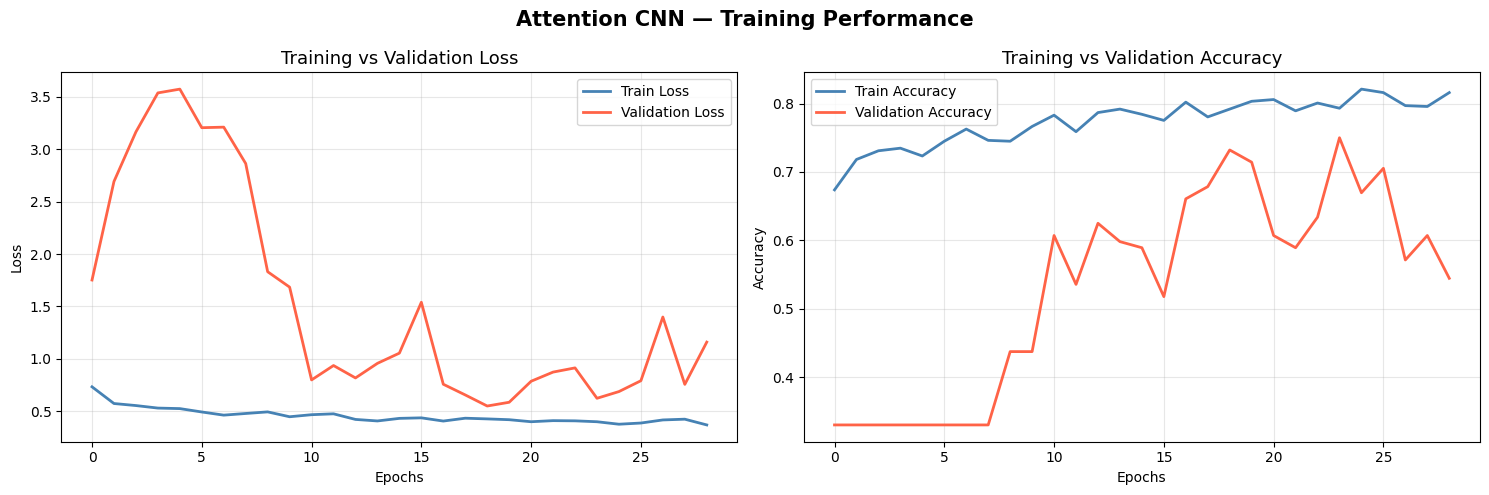

In [ ]:
# CELL 11 — Training Curves (Attention CNN)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#  Loss Curve
axes[0].plot(history.history['loss'],
             label='Train Loss',
             color='steelblue',
             linewidth=2)

axes[0].plot(history.history['val_loss'],
             label='Validation Loss',
             color='tomato',
             linewidth=2)

axes[0].set_title('Training vs Validation Loss', fontsize=13)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy Curve
axes[1].plot(history.history['accuracy'],
             label='Train Accuracy',
             color='steelblue',
             linewidth=2)

axes[1].plot(history.history['val_accuracy'],
             label='Validation Accuracy',
             color='tomato',
             linewidth=2)

axes[1].set_title('Training vs Validation Accuracy', fontsize=13)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Main Title
plt.suptitle('Attention CNN — Training Performance', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# CELL 12 — Test Predictions (Attention CNN)

print("Generating predictions on test set...")
print("-" * 50)

start_test = time.time()

# Predict probabilities
y_pred_probs = model.predict(test_data, verbose=1)

testing_time = time.time() - start_test

# Convert to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = test_data.classes

print(f"\nTesting completed in {testing_time:.4f} seconds")

# Basic Checks
print("\n===== SANITY CHECK =====")
print("Unique predicted classes :", np.unique(y_pred_classes))
print("Unique true classes      :", np.unique(y_true_classes))

# Prediction Distribution
print("\n===== PREDICTION DISTRIBUTION =====")
pred_counts = dict(zip(*np.unique(y_pred_classes, return_counts=True)))

for idx, count in pred_counts.items():
    print(f"{class_names[idx]:10s}: {count} predictions")

# Sample Predictions vs True Labels
print("\n===== SAMPLE PREDICTIONS =====")
print("Predicted:", y_pred_classes[:20])
print("Actual   :", y_true_classes[:20])

#  Confidence Insight
max_conf = np.max(y_pred_probs, axis=1)

print("\n===== CONFIDENCE ANALYSIS =====")
print(f"Average confidence : {np.mean(max_conf)*100:.2f}%")
print(f"Min confidence     : {np.min(max_conf)*100:.2f}%")
print(f"Max confidence     : {np.max(max_conf)*100:.2f}%")

Generating predictions on test set...
--------------------------------------------------
14/14 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step

Testing completed in 54.4155 seconds

===== SANITY CHECK =====
Unique predicted classes : [0 1 2]
Unique true classes      : [0 1 2]

===== PREDICTION DISTRIBUTION =====
Akbar     : 64 predictions
Dilkash   : 50 predictions
urooj     : 110 predictions

===== SAMPLE PREDICTIONS =====
Predicted: [1 2 2 1 2 1 1 2 0 2 2 2 2 2 2 1 0 2 2 0]
Actual   : [1, 2, 1, 1, 0, 1, 1, 2, 0, 1, 2, 2, 2, 1, 1, 1, 0, 2, 0, 0]

===== CONFIDENCE ANALYSIS =====
Average confidence : 80.94%
Min confidence     : 43.53%
Max confidence     : 100.00%


In [ ]:
accuracy = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

y_true_bin = label_binarize(y_true_classes, classes=[0,1,2])
auc_score = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr')

cm = confusion_matrix(y_true_classes, y_pred_classes)
class_acc = cm.diagonal() / cm.sum(axis=1)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("AUC:", auc_score)
print("Training time:", train_time)
print("Testing time:", testing_time)

print("\nClass Accuracy:")
for i, acc in enumerate(class_acc):
    print(f"{class_names[i]}: {acc:.4f}")

Accuracy: 0.7589285714285714
Precision: 0.8021763392857143
Recall: 0.7589285714285714
F1: 0.7607422640031336
AUC: 0.9064159461474898
Training time: 385.7051236629486
Testing time: 54.41553831100464

Class Accuracy:
Akbar: 0.8378
Dilkash: 0.5600
urooj: 0.8800


In [ ]:
# CELL 13 — Detailed Evaluation Metrics (Attention CNN)

print("=" * 55)
print("        ATTENTION CNN — EVALUATION RESULTS")
print("=" * 55)

#  Overall Metrics
accuracy  = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
recall    = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
f1        = f1_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)

#  AUC (multi-class)
y_true_bin = label_binarize(y_true_classes, classes=[0, 1, 2])
auc_score  = roc_auc_score(y_true_bin, y_pred_probs, average='weighted', multi_class='ovr')


#  Class-wise Accuracy
class_acc = cm.diagonal() / cm.sum(axis=1)

#  Print Overall Results
print(f"\n Overall Performance:")
print(f"  Accuracy        : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision       : {precision:.4f}")
print(f"  Recall          : {recall:.4f}")
print(f"  F1-score        : {f1:.4f}")
print(f"  AUC (OvR)       : {auc_score:.4f}")

#  Time Analysis
print(f"\n Time Analysis:")
print(f"  Training Time   : {train_time:.2f} seconds")
print(f"  Testing Time    : {testing_time:.4f} seconds")

#  Class-wise Accuracy
print("\n Class-wise Accuracy:")
for i, acc in enumerate(class_acc):
    print(f"  {class_names[i]:10s}: {acc:.4f} ({acc*100:.2f}%)")



        ATTENTION CNN — EVALUATION RESULTS

 Overall Performance:
  Accuracy        : 0.7589 (75.89%)
  Precision       : 0.8022
  Recall          : 0.7589
  F1-score        : 0.7607
  AUC (OvR)       : 0.9060

 Time Analysis:
  Training Time   : 385.71 seconds
  Testing Time    : 54.4155 seconds

 Class-wise Accuracy:
  Akbar     : 0.8378 (83.78%)
  Dilkash   : 0.5600 (56.00%)
  urooj     : 0.8800 (88.00%)


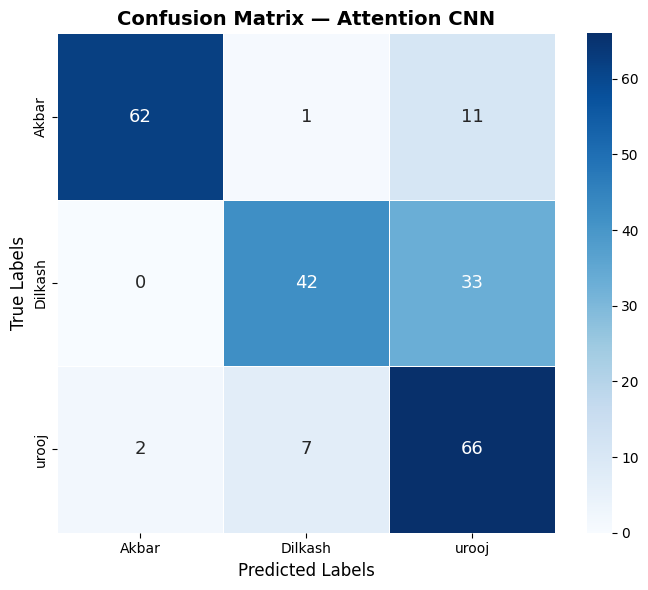


 Confusion Matrix (rows = True class, cols = Predicted):
         Akbar  Dilkash  urooj
Akbar       62        1     11
Dilkash      0       42     33
urooj        2        7     66

 Class-wise Correct Predictions:
  Akbar     : 62/74 correct (83.78%)
  Dilkash   : 42/75 correct (56.00%)
  urooj     : 66/75 correct (88.00%)


In [ ]:
# CELL 14 — Confusion Matrix (Attention CNN)

#  Compute Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

#  Plot Heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    annot_kws={"size": 13}
)

plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.title("Confusion Matrix — Attention CNN", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Text Version
print("\n Confusion Matrix (rows = True class, cols = Predicted):")
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print(cm_df)

#  Extra Insight
print("\n Class-wise Correct Predictions:")
for i in range(len(class_names)):
    correct = cm[i][i]
    total = cm[i].sum()
    print(f"  {class_names[i]:10s}: {correct}/{total} correct ({(correct/total)*100:.2f}%)")



In [ ]:
# CELL 15 — Classification Report (Attention CNN)

print("=" * 55)
print("        CLASSIFICATION REPORT — ATTENTION CNN")
print("=" * 55)

#  Generate Classification Report
report = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\n Detailed Classification Report:")
print(report)

# Extra Structured Output
report_dict = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

print("\n Classification Report (Table Format):")
print(report_df)

# Highlight Best Performing Class
best_class = report_df.loc[class_names, 'f1-score'].idxmax()
best_score = report_df.loc[class_names, 'f1-score'].max()

print("\n Best Performing Class:")
print(f" {best_class} with F1-score = {best_score:.4f}")



        CLASSIFICATION REPORT — ATTENTION CNN

 Detailed Classification Report:
              precision    recall  f1-score   support

       Akbar     0.9688    0.8378    0.8986        74
     Dilkash     0.8400    0.5600    0.6720        75
       urooj     0.6000    0.8800    0.7135        75

    accuracy                         0.7589       224
   macro avg     0.8029    0.7593    0.7614       224
weighted avg     0.8022    0.7589    0.7607       224


 Classification Report (Table Format):
              precision    recall  f1-score     support
Akbar          0.968750  0.837838  0.898551   74.000000
Dilkash        0.840000  0.560000  0.672000   75.000000
urooj          0.600000  0.880000  0.713514   75.000000
accuracy       0.758929  0.758929  0.758929    0.758929
macro avg      0.802917  0.759279  0.761355  224.000000
weighted avg   0.802176  0.758929  0.760742  224.000000

 Best Performing Class:
 Akbar with F1-score = 0.8986


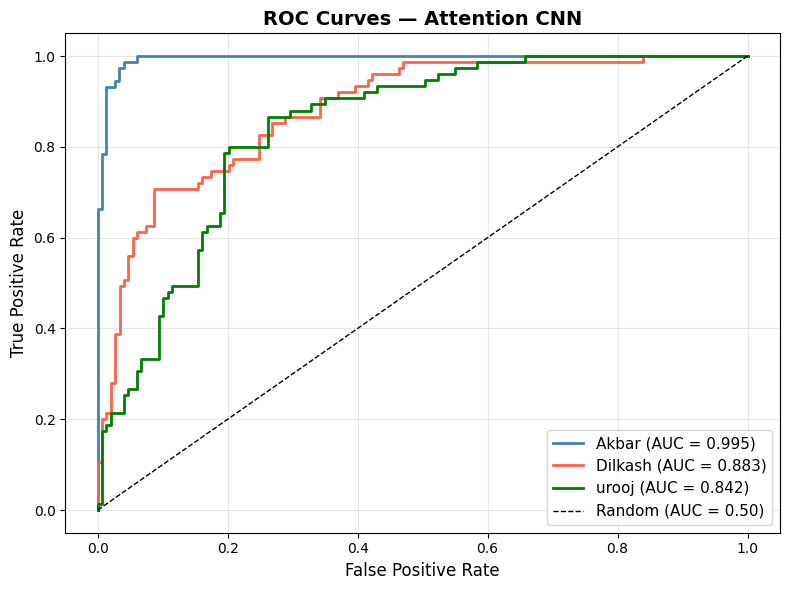


Per-Class AUC Scores:
  Akbar     : 0.9946
  Dilkash   : 0.8825
  urooj     : 0.8421

 Weighted Average AUC: 0.9060


In [ ]:
# CELL 16 — ROC Curve & AUC (Attention CNN)

# Dictionaries to store values
fpr = {}
tpr = {}
roc_auc_dict = {}

# Compute ROC for each class
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc_dict[i] = auc(fpr[i], tpr[i])

#  Plot ROC Curves
plt.figure(figsize=(8, 6))

colors = ['steelblue', 'tomato', 'green']

for i in range(NUM_CLASSES):
    plt.plot(
        fpr[i], tpr[i],
        color=colors[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc_dict[i]:.3f})"
    )

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')

#  Labels & Title
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — Attention CNN", fontsize=14, fontweight='bold')

plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#  Print AUC Scores
print("\nPer-Class AUC Scores:")
for i in range(NUM_CLASSES):
    print(f"  {class_names[i]:10s}: {roc_auc_dict[i]:.4f}")

# Weighted Average AUC (already computed before)
print(f"\n Weighted Average AUC: {auc_score:.4f}")



In [ ]:
#  CELL — Save Task 4 Results (Attention CNN)

import os
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize


os.makedirs(SAVE_PATH, exist_ok=True)

MODEL_NAME = "attentioncnn"


#  1. Correctness Array

correct_array = (y_pred_classes == y_true_classes).astype(int)

np.save(f"{SAVE_PATH}/{MODEL_NAME}_correct.npy", correct_array)

print(f" Saved: {MODEL_NAME}_correct.npy")
print(f"Correct predictions: {correct_array.sum()} / {len(correct_array)}")


#  2. Compute Metrics

accuracy  = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
recall    = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
f1        = f1_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)

y_true_bin = label_binarize(y_true_classes, classes=[0,1,2])
auc_score  = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr')


#  3. Saveed Metrics CSV

metrics_df = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "AUC": [auc_score],
    "Training Time (sec)": [train_time],
    "Testing Time (sec)": [testing_time]
})

metrics_df.to_csv(f"{SAVE_PATH}/{MODEL_NAME}_metrics.csv", index=False)

print(f" Saved: {MODEL_NAME}_metrics.csv")

print("\n Task 4 results saved successfully!")

 Saved: attentioncnn_correct.npy
Correct predictions: 170 / 224
 Saved: attentioncnn_metrics.csv

 Task 4 results saved successfully!
